Wczytywanie konfiguracji...

--- Rozpoczynam Symulację Strategii A (Komfort / Ciągłe) ---
Zakończono A. Zużycie: 4.04 kWh

--- Rozpoczynam Symulację Strategii B (Eco / Oszczędzanie) ---
Zakończono B. Zużycie: 1.63 kWh


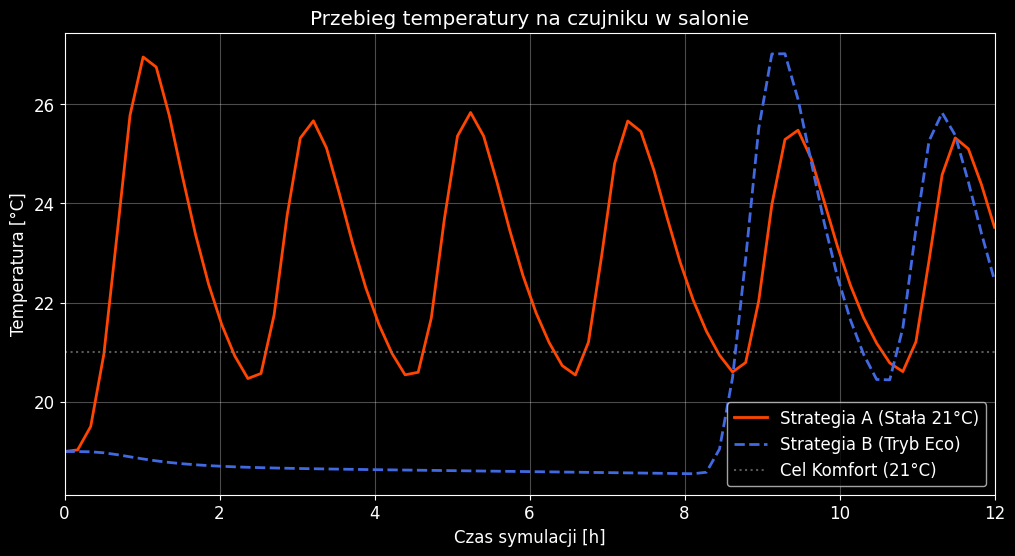

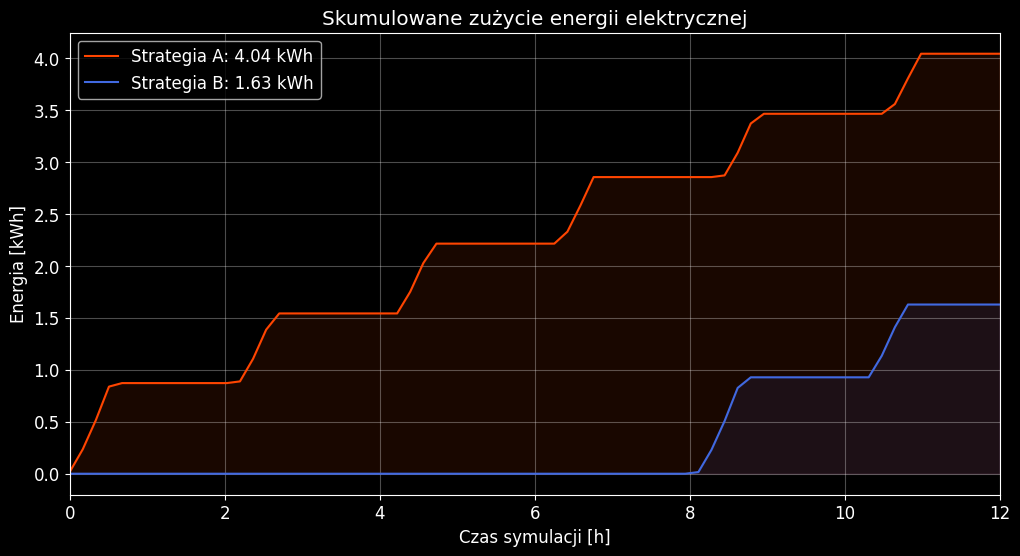

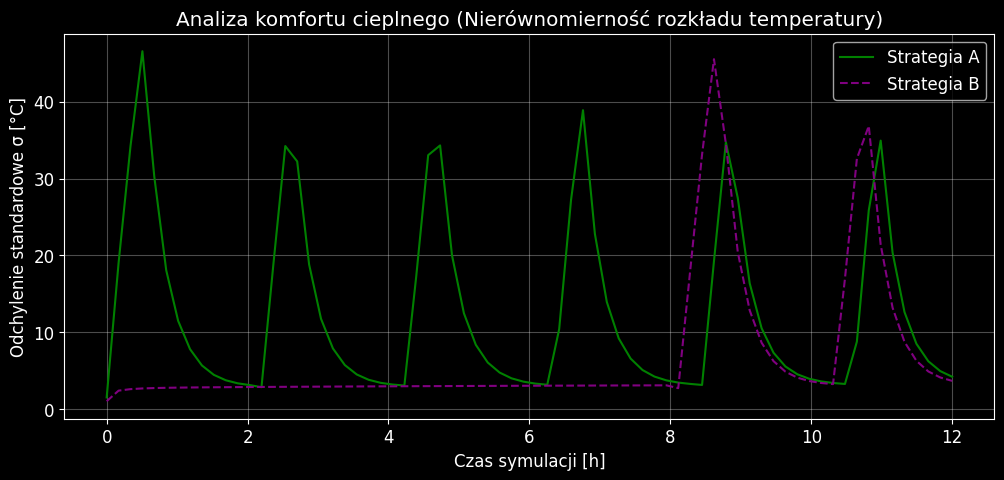

PODSUMOWANIE WYNIKÓW:
Energia zużyta w A: 4.04 kWh
Energia zużyta w B: 1.63 kWh
Oszczędność: 2.41 kWh (59.7%)


In [7]:

import sys
import os
os.environ["PYTHONUTF8"] = "1"
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath('../pipeline'))

from grid import Grid
from solver import Solver

print("Wczytywanie konfiguracji...")
grid = Grid(config_path='data/config.json')
solver = Solver(grid)

print("\n--- Rozpoczynam Symulację Strategii A (Komfort / Ciągłe) ---")
res_A = solver.solve(strategia='A')
print(f"Zakończono A. Zużycie: {res_A['total_kWh']:.2f} kWh")

print("\n--- Rozpoczynam Symulację Strategii B (Eco / Oszczędzanie) ---")
res_B = solver.solve(strategia='B')
print(f"Zakończono B. Zużycie: {res_B['total_kWh']:.2f} kWh")



czas_h = np.linspace(0, solver.c_set['total_time_h'], len(res_A['temp']))

plt.rcParams.update({'font.size': 12})

plt.figure(figsize=(12, 6))
plt.plot(czas_h, res_A['temp'], label='Strategia A (Stała 21°C)', color='orangered', linewidth=2)
plt.plot(czas_h, res_B['temp'], label='Strategia B (Tryb Eco)', color='royalblue', linestyle='--', linewidth=2)

plt.axhline(21, color='gray', linestyle=':', alpha=0.7, label='Cel Komfort (21°C)')

plt.title("Przebieg temperatury na czujniku w salonie")
plt.xlabel("Czas symulacji [h]")
plt.ylabel("Temperatura [°C]")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.xlim(0, solver.c_set['total_time_h'])

plt.show()


plt.figure(figsize=(12, 6))

plt.fill_between(czas_h, res_A['energia'], color='orangered', alpha=0.1)
plt.fill_between(czas_h, res_B['energia'], color='royalblue', alpha=0.1)

plt.plot(czas_h, res_A['energia'], label=f"Strategia A: {res_A['total_kWh']:.2f} kWh", color='orangered')
plt.plot(czas_h, res_B['energia'], label=f"Strategia B: {res_B['total_kWh']:.2f} kWh", color='royalblue')

plt.title("Skumulowane zużycie energii elektrycznej")
plt.xlabel("Czas symulacji [h]")
plt.ylabel("Energia [kWh]")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(0, solver.c_set['total_time_h'])
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(czas_h, res_A['komfort'], label='Strategia A', color='green')
plt.plot(czas_h, res_B['komfort'], label='Strategia B', color='purple', linestyle='--')

plt.title("Analiza komfortu cieplnego (Nierównomierność rozkładu temperatury)")
plt.xlabel("Czas symulacji [h]")
plt.ylabel("Odchylenie standardowe σ [°C]")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

oszczednosc = res_A['total_kWh'] - res_B['total_kWh']
procent = (oszczednosc / res_A['total_kWh']) * 100

print("="*40)
print(f"PODSUMOWANIE WYNIKÓW:")
print(f"Energia zużyta w A: {res_A['total_kWh']:.2f} kWh")
print(f"Energia zużyta w B: {res_B['total_kWh']:.2f} kWh")
print(f"Oszczędność: {oszczednosc:.2f} kWh ({procent:.1f}%)")
print("="*40)

In [8]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

v_min, v_max = -5, 30

im1 = ax1.imshow(res_A['historia'][0], cmap='inferno', vmin=v_min, vmax=v_max, origin='upper')
ax1.set_title("Strategia A: Ciągłe Grzanie")
fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

im2 = ax2.imshow(res_B['historia'][0], cmap='inferno', vmin=v_min, vmax=v_max, origin='upper')
ax2.set_title("Strategia B: Tryb Eco")
fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

time_text = fig.suptitle(f"Czas symulacji: 0.0 h", fontsize=16)

def update(frame):
    im1.set_data(res_A['historia'][frame])
    im2.set_data(res_B['historia'][frame])

    time_h = frame * (10 / 60)
    time_text.set_text(f"Czas symulacji: {time_h:.1f} h")

    return [im1, im2, time_text]


num_frames = len(res_A['historia'])
ani = FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)


plt.close()
HTML(ani.to_jshtml())